In [8]:
# Cell 1: Imports
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import optuna
import timeit

# Ensure notebook can import modules from ./src
ROOT_DIR = Path.cwd()
SRC_DIR = ROOT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Core ELM models now live in src/models/elm.py
from models.elm import (
    ExtremeLearningMachine,
    train_ensemble_elm,
    ensemble_predict,
 )

# Legacy helper utilities (optional compatibility import)
try:
    from elm_utilities import (
        estimate_min_lookback,
        create_lookback_features,
        predict_from_run,
        plot_training_diagnostics,
        analyze_frequency_content,
        check_physical_consistency,
        error_budget_analysis,
    )
except ImportError:
    def _missing_utility(*args, **kwargs):
        raise ImportError(
            "Legacy helper utilities are unavailable. "
            "Port the helper functions into this notebook or a local module."
        )

    estimate_min_lookback = _missing_utility
    create_lookback_features = _missing_utility
    predict_from_run = _missing_utility
    plot_training_diagnostics = _missing_utility
    analyze_frequency_content = _missing_utility
    check_physical_consistency = _missing_utility
    error_budget_analysis = _missing_utility

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
np.set_printoptions(precision=4, suppress=True)

In [9]:
# from pathlib import Path
# import json

# # Add at top of notebook after imports
# OUTPUT_DIR = Path("./outputs")
# OUTPUT_DIR.mkdir(exist_ok=True)

# # Save configuration for reproducibility
# config_path = OUTPUT_DIR / "config.json"
# with open(config_path, 'w') as f:
#     json.dump(config, f, indent=2)
# print(f"Configuration saved to: {config_path}")

# # Then use throughout:
# plot_training_diagnostics(
#     elm_heave_ensemble,
#     features["heave"]["train"]["X"],
#     features["heave"]["train"]["y"],
#     features["heave"]["val"]["X"],
#     features["heave"]["val"]["y"],
#     scalers,
#     "heave",
#     save_path=OUTPUT_DIR / "heave_diagnostics.png"
# )


In [10]:
# Cell 2: Configuration
config = {
    "B": 30.0,  # Deck width (m)
    "U": 10.0,  # Wind velocity (m/s)
    "lookback_steps": 20,  # Will be updated based on physics
    "seed": 42,  # Changed from 10 for better reproducibility
    "motion_types": ["heave", "pitch"],
    
    # Ensemble parameters
    "n_ensemble": 10,
    "use_bagging": True,
    
    # Hyperparameter search ranges
    "hl_range": [50, 400],  # Hidden layer size range
    "hl_step": 10,
    "lam_range": [1e-8, 1e-3],  # Lambda range (log scale)
    
    # Optuna parameters
    "n_trials": 50,  # Reduced from 49 for Bayesian optimization
    "n_jobs": -1,  # Use all cores
    
    # Visualization
    "motion_type": "heave",
    "example_vr": 6.0  # For visualization
}

np.random.seed(config["seed"])

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  B: 30.0
  U: 10.0
  lookback_steps: 20
  seed: 42
  motion_types: ['heave', 'pitch']
  n_ensemble: 10
  use_bagging: True
  hl_range: [50, 400]
  hl_step: 10
  lam_range: [1e-08, 0.001]
  n_trials: 50
  n_jobs: -1
  motion_type: heave
  example_vr: 6.0


In [11]:
# # Cell 3: Load Data
# data_path = "test/simulation_data/flat_plate_data_1.npz"  # Update this path
# runs = np.load(data_path, allow_pickle=True)["data"]

# print(f"\nLoaded {len(runs)} simulation runs")
# print(f"Motion types: {set(r['motion_type'] for r in runs)}")
# print(f"Vr range: {min(r['vr'] for r in runs):.2f} - {max(r['vr'] for r in runs):.2f}")

In [12]:
# Cell 4: Estimate Optimal Lookback
print("\n" + "="*60)
print("ESTIMATING OPTIMAL LOOKBACK WINDOW")
print("="*60)

# Estimate for 2 periods (can try 3 for better wake capture)
min_lookback_2periods = estimate_min_lookback(runs, config["B"], config["U"], n_periods=2)
min_lookback_3periods = estimate_min_lookback(runs, config["B"], config["U"], n_periods=3)

print(f"Minimum lookback for 2 periods: {min_lookback_2periods} steps")
print(f"Minimum lookback for 3 periods: {min_lookback_3periods} steps")
print(f"Current config: {config['lookback_steps']} steps")

if config['lookback_steps'] < min_lookback_2periods:
    print(f"\n⚠️  WARNING: Current lookback may be insufficient!")
    print(f"   Recommendation: Use at least {min_lookback_2periods} steps")
    # Optionally update
    # config['lookback_steps'] = min_lookback_2periods
    print(f"   Updated to: {config['lookback_steps']} steps")
else:
    print(f"\n✓ Current lookback adequate for capturing wake effects")



ESTIMATING OPTIMAL LOOKBACK WINDOW


NameError: name 'runs' is not defined

In [ ]:
# Cell 5: Split by Vr
# Your existing splitting logic here
vr_all = sorted(set(r['vr'] for r in runs))
vr_train = vr_all[::3]  # Every 3rd
vr_val = vr_all[1::3]
vr_test = vr_all[2::3]

print(f"\nVr splits:")
print(f"  Train: {vr_train}")
print(f"  Val: {vr_val}")
print(f"  Test: {vr_test}")

filtered_runs = {}
for motion_type in config["motion_types"]:
    filtered_runs[motion_type] = {
        "train": [r for r in runs if r["motion_type"] == motion_type and r["vr"] in vr_train],
        "val": [r for r in runs if r["motion_type"] == motion_type and r["vr"] in vr_val],
        "test": [r for r in runs if r["motion_type"] == motion_type and r["vr"] in vr_test],
    }
    
    print(f"\n{motion_type.capitalize()} motion:")
    print(f"  Train: {len(filtered_runs[motion_type]['train'])} runs")
    print(f"  Val: {len(filtered_runs[motion_type]['val'])} runs")
    print(f"  Test: {len(filtered_runs[motion_type]['test'])} runs")


Vr splits:
  Train: [2.0, 3.5, 5.0, 6.5, 8.0, 9.5, 11.0, 12.5, 14.0, 15.5]
  Val: [2.5, 4.0, 5.5, 7.0, 8.5, 10.0, 11.5, 13.0, 14.5, 16.0]
  Test: [3.0, 4.5, 6.0, 7.5, 9.0, 10.5, 12.0, 13.5, 15.0]

Heave motion:
  Train: 60 runs
  Val: 60 runs
  Test: 54 runs

Pitch motion:
  Train: 70 runs
  Val: 70 runs
  Test: 63 runs


In [ ]:
# Cell 6: Create Features
print("\n" + "="*60)
print("CREATING LOOKBACK FEATURES")
print("="*60)

features = {}
for motion_type in config["motion_types"]:
    features[motion_type] = {}
    print(f"\n{motion_type.capitalize()} motion:")
    
    for split in ["train", "val", "test"]:
        X, y = create_lookback_features(
            filtered_runs[motion_type][split],
            lookback=config["lookback_steps"],
            B=config["B"],
            U=config["U"]
        )
        features[motion_type][split] = {"X": X, "y": y}
        print(f"  {split}: X shape={X.shape}, y shape={y.shape}")


CREATING LOOKBACK FEATURES

Heave motion:
  train: X shape=(1860, 60), y shape=(1860, 2)
  val: X shape=(1860, 60), y shape=(1860, 2)
  test: X shape=(1680, 60), y shape=(1680, 2)

Pitch motion:
  train: X shape=(2170, 60), y shape=(2170, 2)
  val: X shape=(2170, 60), y shape=(2170, 2)
  test: X shape=(1960, 60), y shape=(1960, 2)


In [ ]:
# Cell 7: Standardization
print("\n" + "="*60)
print("STANDARDIZATION")
print("="*60)

scalers = {}
for motion_type in config["motion_types"]:
    scalers[motion_type] = {
        "X": StandardScaler().fit(features[motion_type]["train"]["X"]),
        "y": StandardScaler().fit(features[motion_type]["train"]["y"])
    }
    
    # Transform all splits
    for split in ["train", "val", "test"]:
        features[motion_type][split]["X"] = scalers[motion_type]["X"].transform(
            features[motion_type][split]["X"]
        )
        features[motion_type][split]["y"] = scalers[motion_type]["y"].transform(
            features[motion_type][split]["y"]
        )
    
    print(f"\n{motion_type.capitalize()} - Feature statistics after scaling:")
    print(f"  X_train: mean={features[motion_type]['train']['X'].mean():.4f}, std={features[motion_type]['train']['X'].std():.4f}")
    print(f"  y_train: mean={features[motion_type]['train']['y'].mean():.4f}, std={features[motion_type]['train']['y'].std():.4f}")


STANDARDIZATION

Heave - Feature statistics after scaling:
  X_train: mean=0.0000, std=1.0000
  y_train: mean=0.0000, std=1.0000

Pitch - Feature statistics after scaling:
  X_train: mean=0.0000, std=1.0000
  y_train: mean=-0.0000, std=1.0000


In [ ]:
# Cell 8: Hyperparameter Optimization with Ensemble Averaging
def objective_with_ensemble(trial, motion_type, n_seeds=3):
    """
    Objective function that averages over multiple random seeds
    to get more stable hyperparameter estimates.
    """
    h = trial.suggest_int("hl", config["hl_range"][0], config["hl_range"][1], step=config["hl_step"])
    lam = trial.suggest_float("lam", config["lam_range"][0], config["lam_range"][1], log=True)
    
    X_train = features[motion_type]["train"]["X"]
    y_train = features[motion_type]["train"]["y"]
    X_val = features[motion_type]["val"]["X"]
    y_val = features[motion_type]["val"]["y"]
    
    mse_list = []
    for seed_offset in range(n_seeds):
        elm = ExtremeLearningMachine(
            X_train.shape[1], h, y_train.shape[1], 
            seed=config["seed"] + seed_offset
        )
        elm.train_model(X_train, y_train, lam)
        y_pred = elm.predict(X_val)
        
        # Inverse transform for evaluation
        y_val_orig = scalers[motion_type]["y"].inverse_transform(y_val)
        y_pred_orig = scalers[motion_type]["y"].inverse_transform(y_pred)
        
        mse = mean_squared_error(y_val_orig, y_pred_orig)
        mse_list.append(mse)
    
    return np.mean(mse_list)  # Average MSE across seeds

In [ ]:
# Cell 9: Optimize Heave
print("\n" + "="*60)
print("HYPERPARAMETER OPTIMIZATION - HEAVE")
print("="*60)

start_time = timeit.default_timer()

study_heave = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=config["seed"]))
study_heave.optimize(
    lambda trial: objective_with_ensemble(trial, "heave", n_seeds=3),
    n_trials=config["n_trials"],
    n_jobs=1,  # Parallel trials don't work well with lambda functions
    show_progress_bar=True
)

elapsed = timeit.default_timer() - start_time

print(f"\n✓ Optimization complete in {elapsed:.2f}s")
print(f"Best params: {study_heave.best_params}")
print(f"Best MSE: {study_heave.best_value:.6f}")

[I 2025-11-04 17:46:31,190] A new study created in memory with name: no-name-f454c9a3-7ace-4f9c-8788-2f04e7bf23e8



HYPERPARAMETER OPTIMIZATION - HEAVE


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-04 17:46:31,579] Trial 0 finished with value: 27.297171934944043 and parameters: {'hl': 180, 'lam': 0.0005669849511478851}. Best is trial 0 with value: 27.297171934944043.
[I 2025-11-04 17:46:32,258] Trial 1 finished with value: 972.9321140292597 and parameters: {'hl': 310, 'lam': 9.846738873614555e-06}. Best is trial 0 with value: 27.297171934944043.
[I 2025-11-04 17:46:32,436] Trial 2 finished with value: 36.896632923946704 and parameters: {'hl': 100, 'lam': 6.02521573620385e-08}. Best is trial 0 with value: 27.297171934944043.
[I 2025-11-04 17:46:32,553] Trial 3 finished with value: 143.41315249516114 and parameters: {'hl': 70, 'lam': 0.00021423021757741048}. Best is trial 0 with value: 27.297171934944043.
[I 2025-11-04 17:46:33,083] Trial 4 finished with value: 174.86901881084023 and parameters: {'hl': 260, 'lam': 3.47026698865041e-05}. Best is trial 0 with value: 27.297171934944043.
[I 2025-11-04 17:46:33,147] Trial 5 finished with value: 96.21857067492105 and parameter

In [ ]:
# Cell 10: Train Heave Ensemble
print("\n" + "="*60)
print("TRAINING HEAVE ENSEMBLE")
print("="*60)

h_best = study_heave.best_params['hl']
lam_best = study_heave.best_params['lam']

elm_heave_ensemble = train_ensemble_elm(
    features["heave"]["train"]["X"],
    features["heave"]["train"]["y"],
    hidden_size=h_best,
    lambda_reg=lam_best,
    n_models=config["n_ensemble"],
    base_seed=config["seed"],
    use_bagging=config["use_bagging"],
    verbose=True
)


TRAINING HEAVE ENSEMBLE
Training ensemble of 10 ELM models...
  Hidden size: 270
  Lambda: 7.42e-04
  Bagging: True
  Trained 2/10 models
  Trained 4/10 models
  Trained 6/10 models
  Trained 8/10 models
  Trained 10/10 models
✓ Ensemble training complete


In [ ]:
# Cell 9: Optimize pitch
print("\n" + "="*60)
print("HYPERPARAMETER OPTIMIZATION - HEAVE")
print("="*60)

start_time = timeit.default_timer()

study_pitch = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=config["seed"]))
study_pitch.optimize(
    lambda trial: objective_with_ensemble(trial, "pitch", n_seeds=3),
    n_trials=config["n_trials"],
    n_jobs=1,  # Parallel trials don't work well with lambda functions
    show_progress_bar=True
)

elapsed = timeit.default_timer() - start_time

print(f"\n✓ Optimization complete in {elapsed:.2f}s")
print(f"Best params: {study_pitch.best_params}")
print(f"Best MSE: {study_pitch.best_value:.6f}")

[I 2025-11-04 18:27:31,942] A new study created in memory with name: no-name-d55fcf3d-86f7-43e7-8db9-3eb13318e8ab



HYPERPARAMETER OPTIMIZATION - HEAVE


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-04 18:27:32,332] Trial 0 finished with value: 10.791031925607038 and parameters: {'hl': 180, 'lam': 0.0005669849511478851}. Best is trial 0 with value: 10.791031925607038.
[I 2025-11-04 18:27:33,035] Trial 1 finished with value: 15.151071327584432 and parameters: {'hl': 310, 'lam': 9.846738873614555e-06}. Best is trial 0 with value: 10.791031925607038.
[I 2025-11-04 18:27:33,220] Trial 2 finished with value: 18.38277759261153 and parameters: {'hl': 100, 'lam': 6.02521573620385e-08}. Best is trial 0 with value: 10.791031925607038.
[I 2025-11-04 18:27:33,333] Trial 3 finished with value: 22.943483700987997 and parameters: {'hl': 70, 'lam': 0.00021423021757741048}. Best is trial 0 with value: 10.791031925607038.
[I 2025-11-04 18:27:33,894] Trial 4 finished with value: 12.84425184069777 and parameters: {'hl': 260, 'lam': 3.47026698865041e-05}. Best is trial 0 with value: 10.791031925607038.
[I 2025-11-04 18:27:33,963] Trial 5 finished with value: 15.611194126661468 and parameter

In [ ]:
# Cell 10: Train Heave Ensemble
print("\n" + "="*60)
print("TRAINING PITCH ENSEMBLE")
print("="*60)

h_best_p = study_pitch.best_params['hl']
lam_best_p = study_pitch.best_params['lam']

elm_pitch_ensemble = train_ensemble_elm(
    features["pitch"]["train"]["X"],
    features["pitch"]["train"]["y"],
    hidden_size=h_best_p,
    lambda_reg=lam_best_p,
    n_models=config["n_ensemble"],
    base_seed=config["seed"],
    use_bagging=config["use_bagging"],
    verbose=True
)


TRAINING PITCH ENSEMBLE
Training ensemble of 10 ELM models...
  Hidden size: 80
  Lambda: 5.10e-07
  Bagging: True
  Trained 2/10 models
  Trained 4/10 models
  Trained 6/10 models
  Trained 8/10 models
  Trained 10/10 models
✓ Ensemble training complete



PITCH DIAGNOSTICS


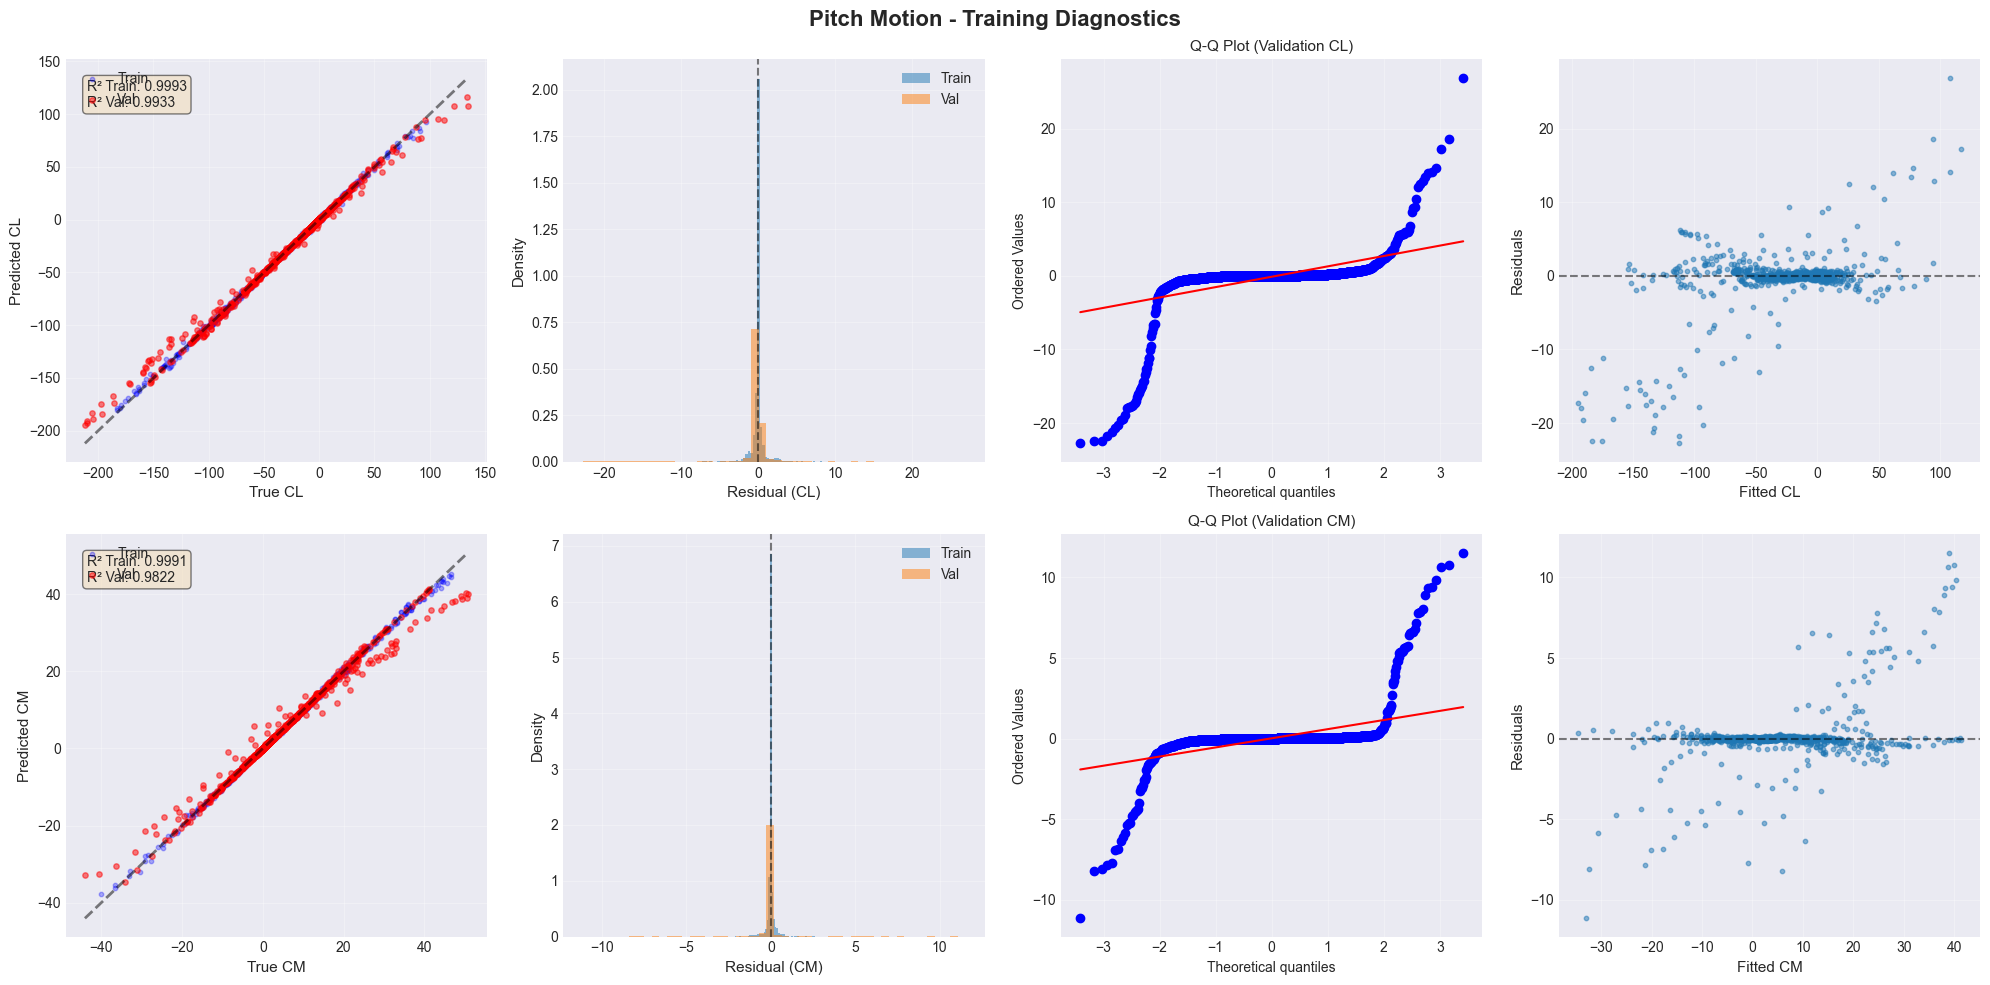

In [ ]:
# Cell 11: Heave Diagnostics
print("\n" + "="*60)
print("PITCH DIAGNOSTICS")
print("="*60)

plot_training_diagnostics(
    elm_pitch_ensemble,
    features["pitch"]["train"]["X"],
    features["pitch"]["train"]["y"],
    features["pitch"]["val"]["X"],
    features["pitch"]["val"]["y"],
    scalers,
    "pitch",
    save_path="pitch_diagnostics.png"
)



HEAVE DIAGNOSTICS


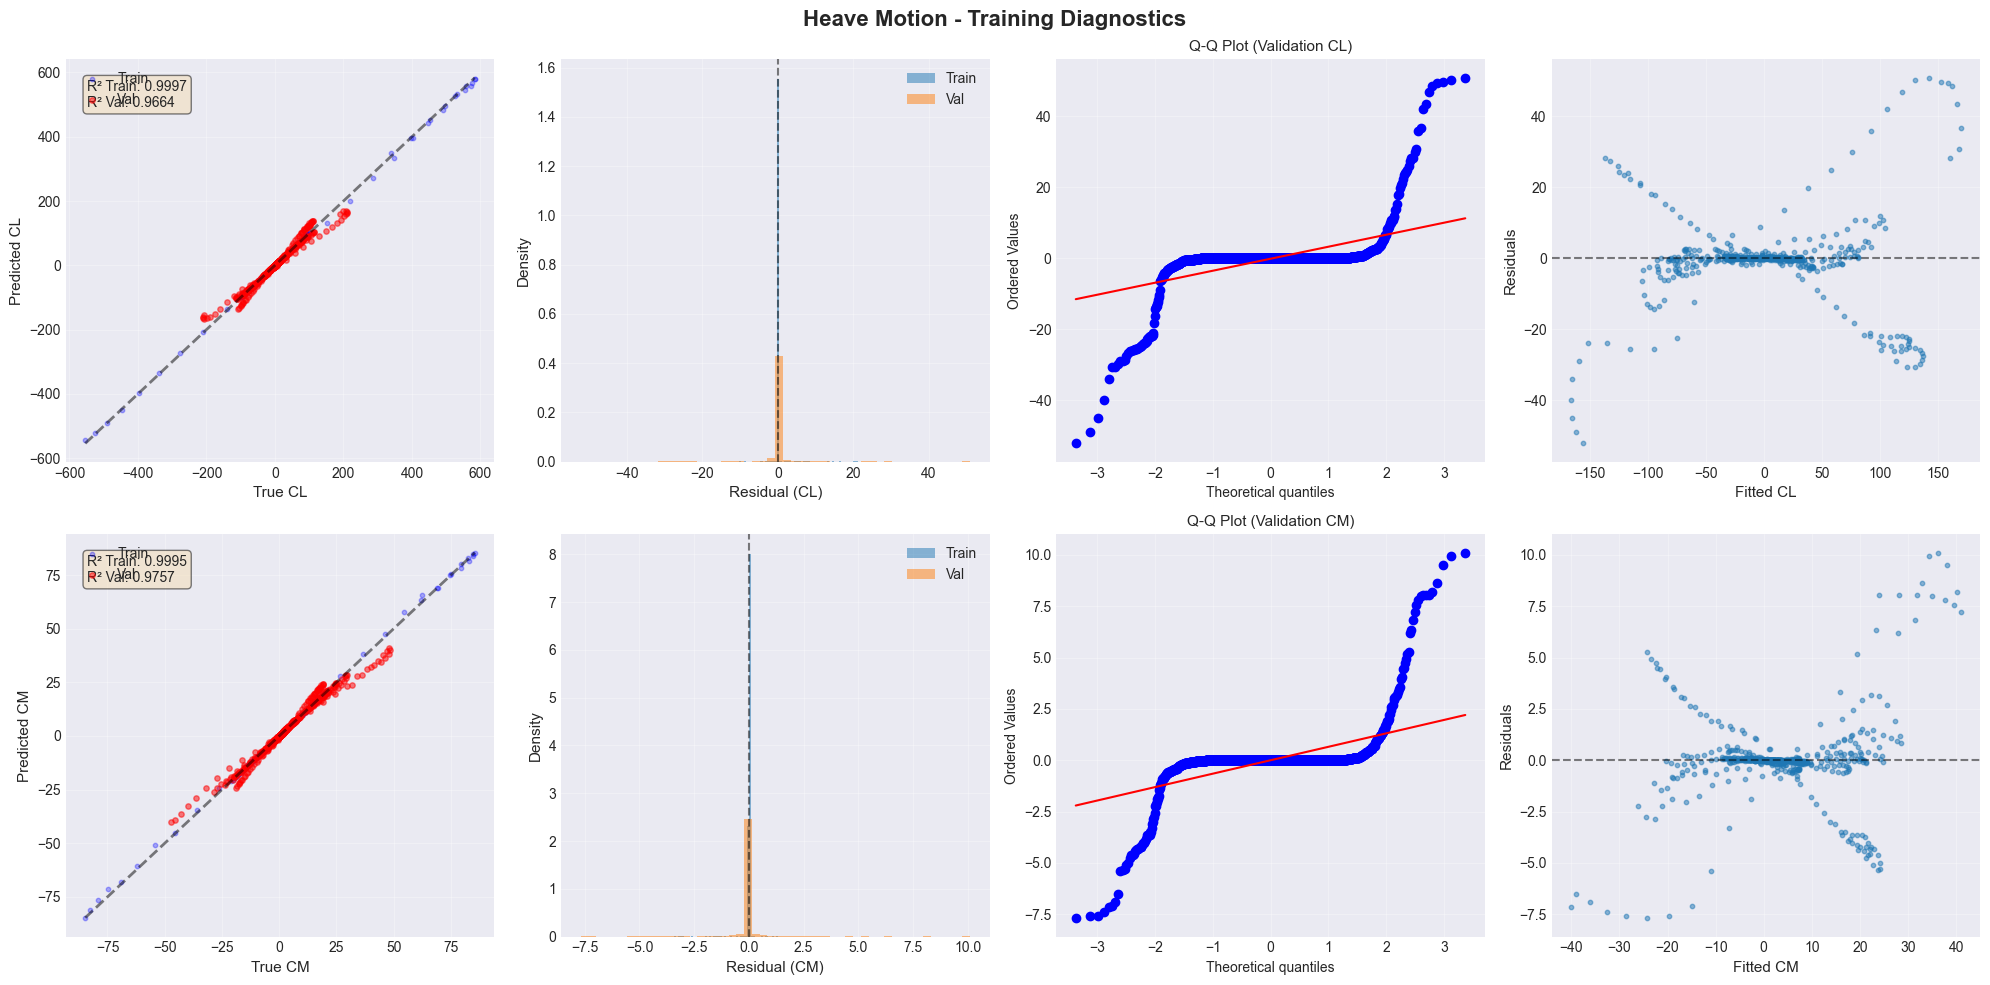

In [ ]:
# Cell 11: Heave Diagnostics
print("\n" + "="*60)
print("HEAVE DIAGNOSTICS")
print("="*60)

plot_training_diagnostics(
    elm_heave_ensemble,
    features["heave"]["train"]["X"],
    features["heave"]["train"]["y"],
    features["heave"]["val"]["X"],
    features["heave"]["val"]["y"],
    scalers,
    "heave",
    save_path="heave_diagnostics.png"
)


In [ ]:
# Cell 13: Prediction with Uncertainty
print("\n" + "="*60)
print("GENERATING PREDICTIONS WITH UNCERTAINTY")
print("="*60)

# Select example run
example_run_pitch = [r for r in filtered_runs["pitch"]["test"] if abs(r["vr"] - config["example_vr"]) < 0.1][0]

CL_pred, CM_pred, CL_std, CM_std, pos, y_true = predict_from_run(
    elm_pitch_ensemble,
    scalers,
    example_run_pitch,
    config["lookback_steps"],
    config["B"],
    config["U"],
    "pitch"
)


GENERATING PREDICTIONS WITH UNCERTAINTY


In [ ]:
# Cell 13: Prediction with Uncertainty
print("\n" + "="*60)
print("GENERATING PREDICTIONS WITH UNCERTAINTY")
print("="*60)

# Select example run
example_run = [r for r in filtered_runs["heave"]["test"] if abs(r["vr"] - config["example_vr"]) < 0.1][0]

CL_pred, CM_pred, CL_std, CM_std, pos, y_true = predict_from_run(
    elm_heave_ensemble,
    scalers,
    example_run,
    config["lookback_steps"],
    config["B"],
    config["U"],
    "heave"
)


GENERATING PREDICTIONS WITH UNCERTAINTY


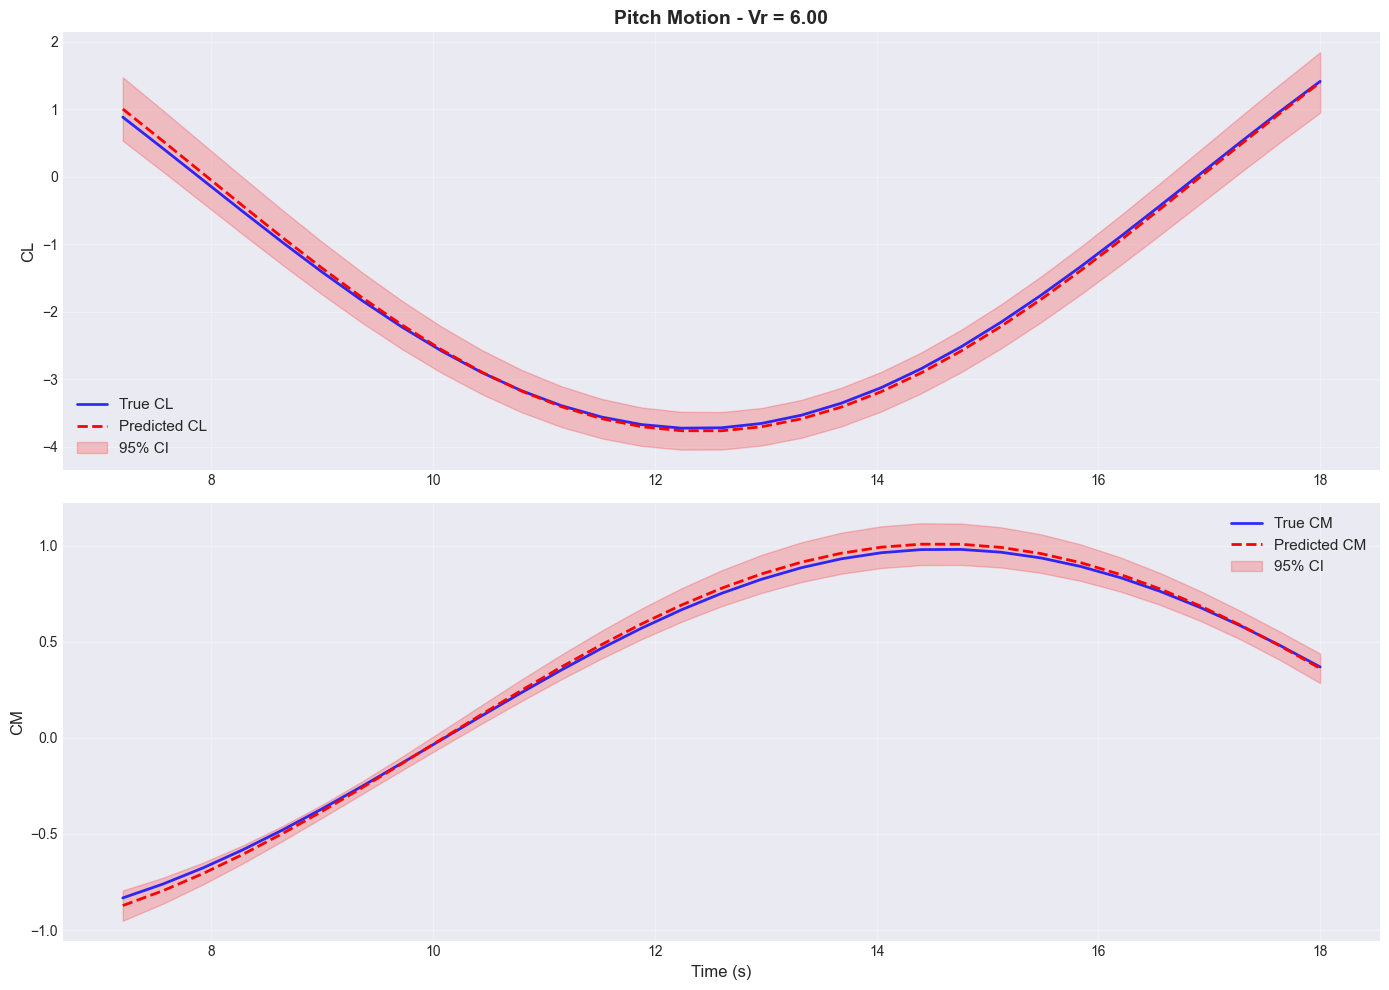

In [ ]:
# Cell 14: Visualization with Uncertainty Bands
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

time_ex = example_run_pitch["time"][config['lookback_steps']:]

# CL with uncertainty
axes[0].plot(time_ex, y_true[:, 0], 'b-', label='True CL', linewidth=2, alpha=0.8)
axes[0].plot(time_ex, CL_pred, 'r--', label='Predicted CL', linewidth=2)
axes[0].fill_between(time_ex, CL_pred - 2*CL_std, CL_pred + 2*CL_std, 
                      color='red', alpha=0.2, label='95% CI')
axes[0].set_ylabel('CL', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_title(f'Pitch Motion - Vr = {example_run["vr"]:.2f}', fontsize=14, fontweight='bold')

# CM with uncertainty
axes[1].plot(time_ex, y_true[:, 1], 'b-', label='True CM', linewidth=2, alpha=0.8)
axes[1].plot(time_ex, CM_pred, 'r--', label='Predicted CM', linewidth=2)
axes[1].fill_between(time_ex, CM_pred - 2*CM_std, CM_pred + 2*CM_std, 
                      color='red', alpha=0.2, label='95% CI')
axes[1].set_xlabel('Time (s)', fontsize=12)
axes[1].set_ylabel('CM', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_with_uncertainty.png', dpi=300, bbox_inches='tight')
plt.show()

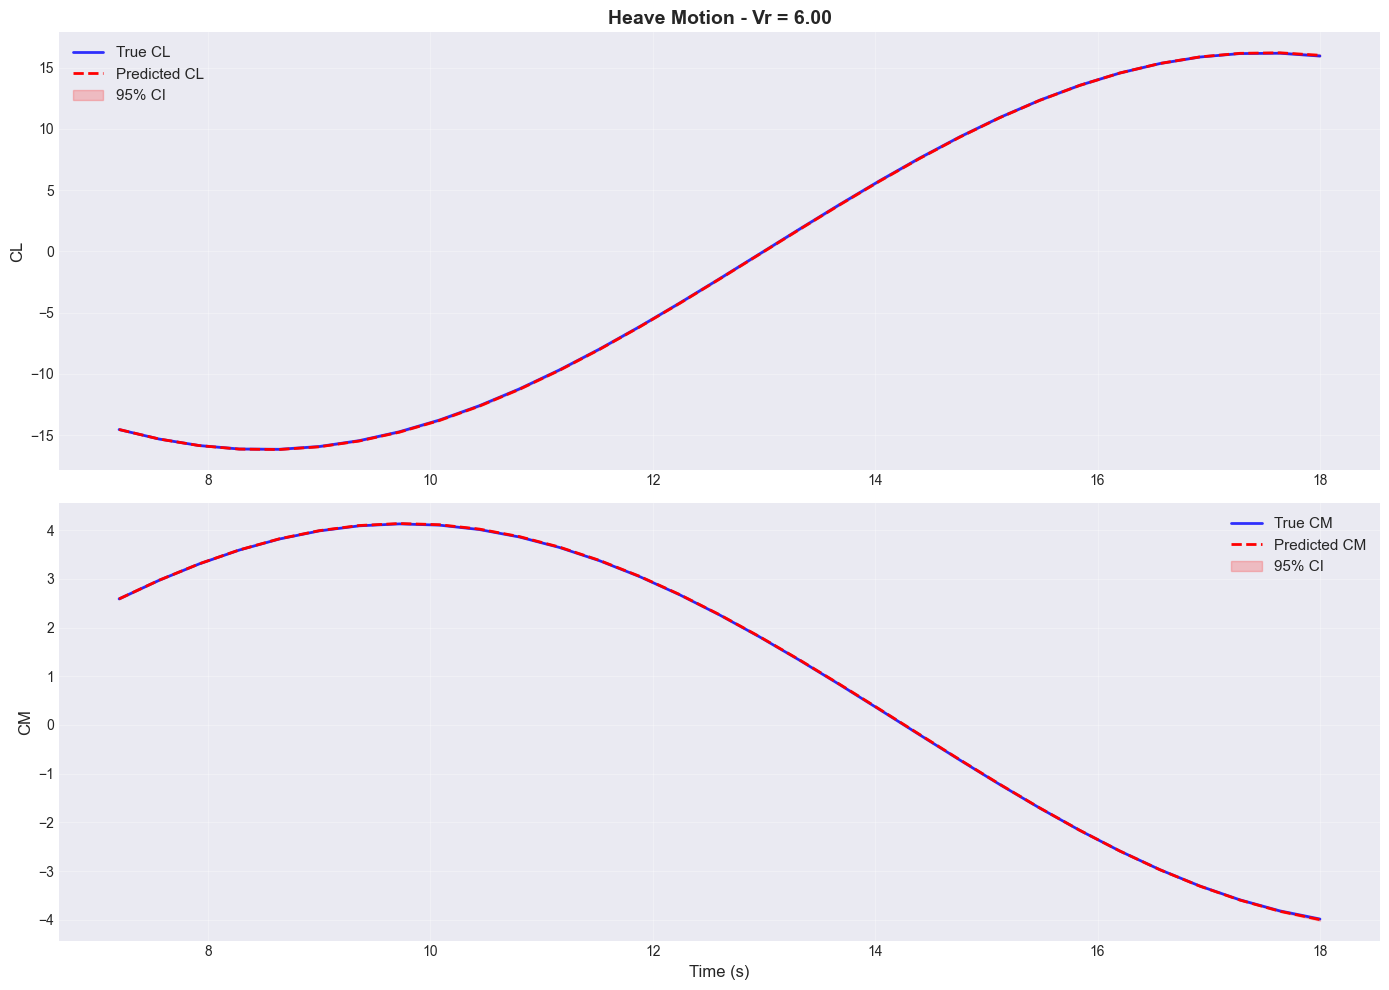

In [ ]:
# Cell 14: Visualization with Uncertainty Bands
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

time_ex = example_run["time"][config['lookback_steps']:]

# CL with uncertainty
axes[0].plot(time_ex, y_true[:, 0], 'b-', label='True CL', linewidth=2, alpha=0.8)
axes[0].plot(time_ex, CL_pred, 'r--', label='Predicted CL', linewidth=2)
axes[0].fill_between(time_ex, CL_pred - 2*CL_std, CL_pred + 2*CL_std, 
                      color='red', alpha=0.2, label='95% CI')
axes[0].set_ylabel('CL', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_title(f'Heave Motion - Vr = {example_run["vr"]:.2f}', fontsize=14, fontweight='bold')

# CM with uncertainty
axes[1].plot(time_ex, y_true[:, 1], 'b-', label='True CM', linewidth=2, alpha=0.8)
axes[1].plot(time_ex, CM_pred, 'r--', label='Predicted CM', linewidth=2)
axes[1].fill_between(time_ex, CM_pred - 2*CM_std, CM_pred + 2*CM_std, 
                      color='red', alpha=0.2, label='95% CI')
axes[1].set_xlabel('Time (s)', fontsize=12)
axes[1].set_ylabel('CM', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_with_uncertainty.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Add this as a new cell in the notebook
print("\n" + "="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)

test_results = {}

for motion_type in config["motion_types"]:
    print(f"\n{motion_type.upper()} MOTION:")
    print("-" * 40)
    
    # Get test data
    X_test = features[motion_type]["test"]["X"]
    y_test = features[motion_type]["test"]["y"]
    
    # Select appropriate ensemble
    if motion_type == "heave":
        ensemble = elm_heave_ensemble
    else:
        ensemble = elm_pitch_ensemble
    
    # Predict with uncertainty
    y_pred_scaled, y_std_scaled = ensemble_predict(ensemble, X_test)
    
    # Inverse transform
    y_test_orig = scalers[motion_type]["y"].inverse_transform(y_test)
    y_pred_orig = scalers[motion_type]["y"].inverse_transform(y_pred_scaled)
    y_std_orig = y_std_scaled * scalers[motion_type]["y"].scale_
    
    # Compute comprehensive metrics
    mse_total = mean_squared_error(y_test_orig, y_pred_orig)
    rmse_total = np.sqrt(mse_total)
    r2_total = r2_score(y_test_orig, y_pred_orig)
    
    # Per-output metrics
    mse_cl = mean_squared_error(y_test_orig[:, 0], y_pred_orig[:, 0])
    rmse_cl = np.sqrt(mse_cl)
    r2_cl = r2_score(y_test_orig[:, 0], y_pred_orig[:, 0])
    mae_cl = np.mean(np.abs(y_test_orig[:, 0] - y_pred_orig[:, 0]))
    
    mse_cm = mean_squared_error(y_test_orig[:, 1], y_pred_orig[:, 1])
    rmse_cm = np.sqrt(mse_cm)
    r2_cm = r2_score(y_test_orig[:, 1], y_pred_orig[:, 1])
    mae_cm = np.mean(np.abs(y_test_orig[:, 1] - y_pred_orig[:, 1]))
    
    # Average prediction uncertainty
    avg_std_cl = np.mean(y_std_orig[:, 0])
    avg_std_cm = np.mean(y_std_orig[:, 1])
    
    # Store results
    test_results[motion_type] = {
        'mse_total': mse_total,
        'r2_total': r2_total,
        'CL': {'mse': mse_cl, 'rmse': rmse_cl, 'r2': r2_cl, 'mae': mae_cl, 'avg_std': avg_std_cl},
        'CM': {'mse': mse_cm, 'rmse': rmse_cm, 'r2': r2_cm, 'mae': mae_cm, 'avg_std': avg_std_cm}
    }
    
    # Print results
    print(f"  Overall:  MSE={mse_total:.6f}, RMSE={rmse_total:.6f}, R²={r2_total:.4f}")
    print(f"\n  CL (Lift Coefficient):")
    print(f"    MSE  = {mse_cl:.6f}")
    print(f"    RMSE = {rmse_cl:.6f}")
    print(f"    MAE  = {mae_cl:.6f}")
    print(f"    R²   = {r2_cl:.4f}")
    print(f"    Avg Uncertainty = ±{avg_std_cl:.4f}")
    
    print(f"\n  CM (Moment Coefficient):")
    print(f"    MSE  = {mse_cm:.6f}")
    print(f"    RMSE = {rmse_cm:.6f}")
    print(f"    MAE  = {mae_cm:.6f}")
    print(f"    R²   = {r2_cm:.4f}")
    print(f"    Avg Uncertainty = ±{avg_std_cm:.4f}")
    
    # Calibration check: Are uncertainties realistic?
    residuals_cl = np.abs(y_test_orig[:, 0] - y_pred_orig[:, 0])
    within_1sigma = np.mean(residuals_cl <= y_std_orig[:, 0])
    within_2sigma = np.mean(residuals_cl <= 2 * y_std_orig[:, 0])
    
    print(f"\n  Uncertainty Calibration (CL):")
    print(f"    Within 1σ: {within_1sigma*100:.1f}% (expect ~68%)")
    print(f"    Within 2σ: {within_2sigma*100:.1f}% (expect ~95%)")
    
    if within_2sigma < 0.90:
        print(f"    ⚠️  Uncertainties may be underestimated!")
    elif within_2sigma > 0.98:
        print(f"    ⚠️  Uncertainties may be overestimated!")
    else:
        print(f"    ✓ Uncertainties well-calibrated")

print("\n" + "="*60)

# Create comparison table
print("\n" + "="*60)
print("TEST SET PERFORMANCE SUMMARY")
print("="*60)
print(f"\n{'Motion':<10} {'Output':<8} {'RMSE':<12} {'MAE':<12} {'R²':<12}")
print("-" * 56)
for motion_type in config["motion_types"]:
    res = test_results[motion_type]
    print(f"{motion_type.capitalize():<10} {'CL':<8} {res['CL']['rmse']:<12.6f} {res['CL']['mae']:<12.6f} {res['CL']['r2']:<12.4f}")
    print(f"{'':10} {'CM':<8} {res['CM']['rmse']:<12.6f} {res['CM']['mae']:<12.6f} {res['CM']['r2']:<12.4f}")
print("="*60)



FINAL TEST SET EVALUATION

HEAVE MOTION:
----------------------------------------
  Overall:  MSE=48.209694, RMSE=6.943320, R²=0.9368

  CL (Lift Coefficient):
    MSE  = 92.734700
    RMSE = 9.629886
    MAE  = 1.895980
    R²   = 0.9298
    Avg Uncertainty = ±1.2279

  CM (Moment Coefficient):
    MSE  = 3.684689
    RMSE = 1.919554
    MAE  = 0.380752
    R²   = 0.9439
    Avg Uncertainty = ±0.2783

  Uncertainty Calibration (CL):
    Within 1σ: 23.4% (expect ~68%)
    Within 2σ: 40.3% (expect ~95%)
    ⚠️  Uncertainties may be underestimated!

PITCH MOTION:
----------------------------------------
  Overall:  MSE=114.563548, RMSE=10.703436, R²=0.9129

  CL (Lift Coefficient):
    MSE  = 210.478765
    RMSE = 14.507886
    MAE  = 2.710361
    R²   = 0.9192
    Avg Uncertainty = ±2.2422

  CM (Moment Coefficient):
    MSE  = 18.648332
    RMSE = 4.318371
    MAE  = 0.863018
    R²   = 0.9065
    Avg Uncertainty = ±0.5651

  Uncertainty Calibration (CL):
    Within 1σ: 93.9% (expect 

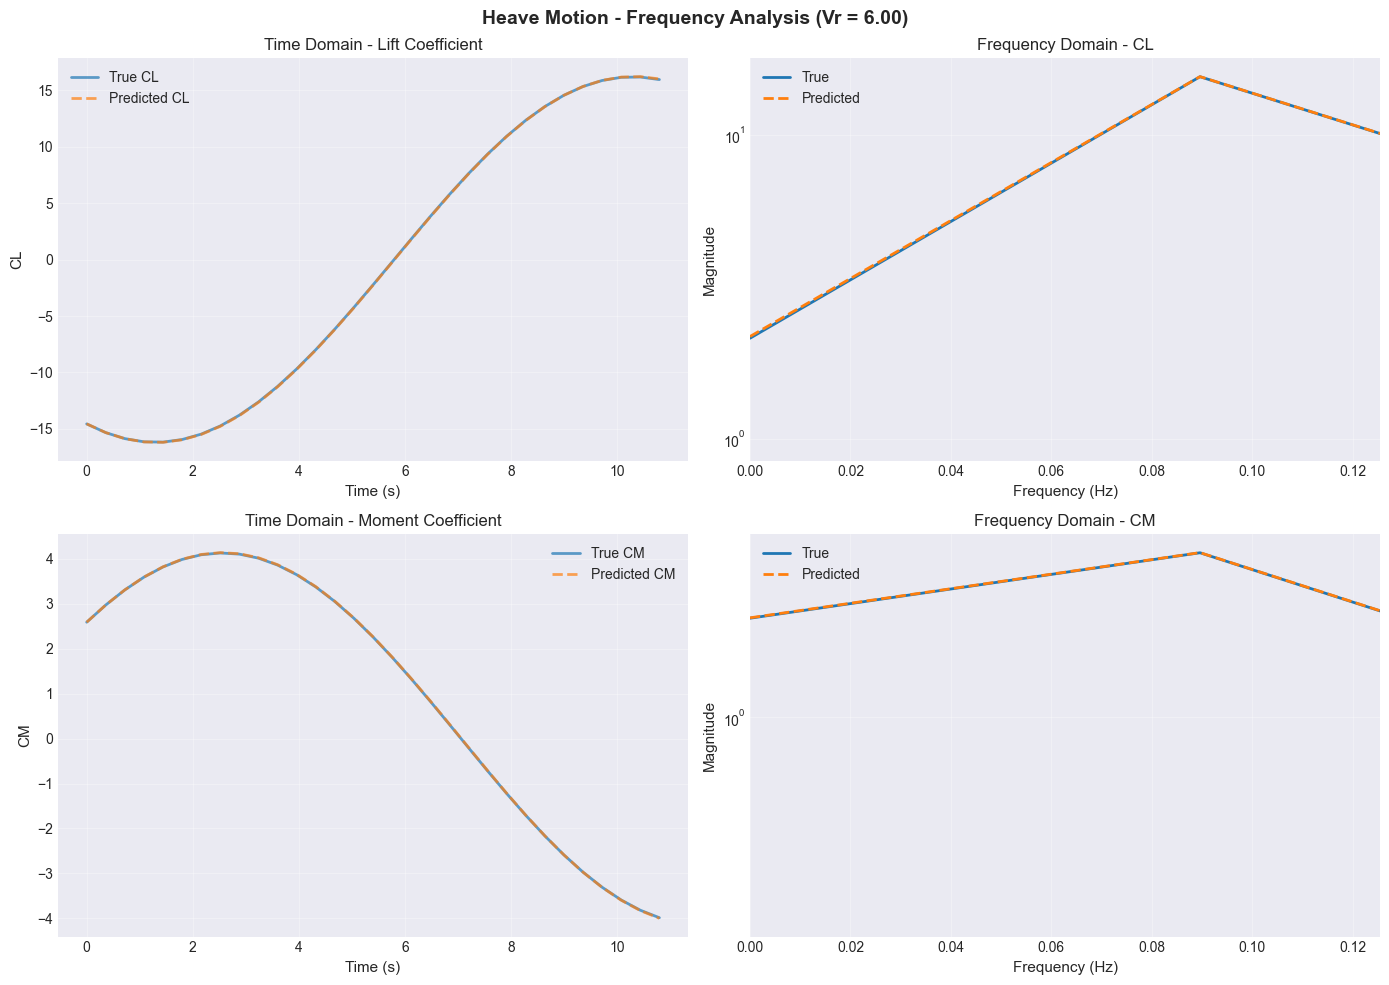

In [ ]:
# Cell 15: Frequency Analysis
dt = np.mean(np.diff(example_run["time"]))
analyze_frequency_content(
    y_true, 
    np.column_stack([CL_pred, CM_pred]),
    dt,
    example_run["vr"],
    title="Heave Motion",
    save_path="frequency_analysis.png"
)

# Cell 16: Flutter Derivatives Extraction
# [Your existing derivative extraction code]

# # Cell 17: Physical Consistency Check
# check_physical_consistency(
#     derivatives_dict_heave,
#     vr_list,
#     "heave"
# )




